# Beer Expert Panel (S1 + S4) — 6-way Comparison  
## Bootstrap / KDE / Gaussian Copula / VAE / CTGAN / TabDDPM (4090 eGPU)

이 노트북은 업로드된 **`Supplemental Files and Figure source files.xlsx`**를 직접 사용하여,  
**전문가(Trained Panel) 관능평가 데이터만** 활용합니다. (RateBeer/일반인 리뷰 미사용)

---

## 사용할 시트 (고정)
- **X (Chemistry)**: `Supplementary File S1`
  - feature 범위: `acetaldehyde` ~ `sulfur_sum` (231 features)
- **Y (Expert sensory panel)**: `Supplementary File S4`
  - target 범위: `A_malt_all` ~ `overall` (50 targets)

join key: `beer_id` (unique)

---

## 비교할 6가지 생성 방법
1) **Bootstrapping**
2) **Independent KDE** (marginals only)
3) **Multivariate Gaussian Copula**
4) **VAE** (직접 구현, GPU/AMP)
5) **CTGAN** (설치되어 있으면 사용)
6) **TabDDPM** (Tabular DDPM, PyTorch 구현, GPU/AMP)

---

## 평가 (논문 요구)
### Phase 1 — Validity & Fidelity
- KS-test (feature-wise)
- PCD (Pairwise Correlation Difference) : shrinkage corr 기반
- DCR (Distance to Closest Record) : memorization/outlier

### Phase 2 — Utility (TSTR)
- Train on Synthetic, Test on Real
- Regressor: Torch MLP (GPU) + (옵션) XGBoost (overall만)

---

## 4090 eGPU 최적화
- PyTorch: CUDA + AMP(BF16/FP16)
- DCR: `torch.cdist` GPU chunk
- TabDDPM: timestep/샘플수 조절로 속도-품질 트레이드오프 가능

## 0. 경로 설정
당신 PC 기준:
`C:\Users\eys63\Desktop\맥주데이터실험\data`

> 노트북과 같은 폴더에 xlsx를 두었다면 자동으로 fallback합니다.

In [2]:

from pathlib import Path

DATA_DIR  = Path(r"C:\Users\eys63\Desktop\맥주데이터실험\data")
DATA_PATH = DATA_DIR / "Supplemental Files and Figure source files.xlsx"

# fallback: current working directory
if not DATA_PATH.exists():
    alt = Path("Supplemental Files and Figure source files.xlsx")
    if alt.exists():
        DATA_PATH = alt

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

DATA_PATH: C:\Users\eys63\Desktop\맥주데이터실험\data\Supplemental Files and Figure source files.xlsx
Exists: True


## 0-1. (선택) 패키지 설치
CTGAN / XGBoost를 사용할 경우 설치가 필요할 수 있습니다.

In [3]:

# !pip -q install xgboost
# !pip -q install ctgan
# 또는 sdv 기반 CTGAN:
# !pip -q install sdv

## 1. Import + 4090 eGPU (CUDA/AMP) 설정  
Python 3.8+ 호환 (3.10 문법 `str | None` 사용 안 함)

In [4]:

import os, math, time, random
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

USE_AMP = (DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))
print("USE_AMP =", USE_AMP, "| AMP_DTYPE =", AMP_DTYPE, "| GradScaler enabled =", SCALER.is_enabled())

DEVICE = cuda
GPU: NVIDIA GeForce RTX 4090
VRAM(GB): 25.756696576
USE_AMP = True | AMP_DTYPE = torch.bfloat16 | GradScaler enabled = False


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\2735964977.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


## 2. 데이터 로드 (xlsx 직접 읽기)
고정 시트:
- `Supplementary File S1` (chemistry)
- `Supplementary File S4` (expert panel)

In [5]:

xls = pd.ExcelFile(DATA_PATH)
print("Sheets:", len(xls.sheet_names))
print(xls.sheet_names)

S1_SHEET = "Supplementary File S1"
S4_SHEET = "Supplementary File S4"

chem  = xls.parse(S1_SHEET)
panel = xls.parse(S4_SHEET)

print("chem shape :", chem.shape)
print("panel shape:", panel.shape)

display(chem.head(3))
display(panel.head(3))

Sheets: 29
['Supplementary File S1', 'Supplementary File S2', 'Supplementary File S3', 'Supplementary File S4', 'Supplementary File S5', 'Supplementary File S6', 'Supplementary File S7', 'Supplementary Table S1', 'Supplementary Table S2', 'Supplementary Table S3', 'Supplementary Table S4', 'Supplementary Table S5', 'Supplementary Table S6', 'Supplementary Table S7', 'Sensory thresholds', 'Sensory names', 'Validation Results 1', 'Validation Results 2', 'Validation Results 3', 'Validation Concentrations', 'Validation Details', 'GBM importance MDI', 'GBM SHAP Values', 'Calibrated chemical dataset', 'Beer Prices', 'Performance of 100 models', '100 models feature importance', 'GBM model on merged dataset', 'GBM model with style informatio']
chem shape : (250, 234)
panel shape: (250, 53)


,beer,beer_id,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,...,X13.epi.manool.oxide,isopropyl.hexadecanoate,manool,ethyl.octadecanoate,ethyl.pentanoate,X2.ethyl.3.methylpyrazine,esters_sum,aroma_hops_sum,acids_sum,sulfur_sum
0,10,5410228202929,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,...,4.360243,-1.817819,5.721204,4.438951,0.014728,0.054353,-0.532634,3.696586,0.244085,0.166286
1,86,5410783031019,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,...,4.512589,4.323292,5.810501,4.247826,0.023167,0.001400,-0.465401,1.219563,-0.152156,0.098931
2,2,5410228142003,Low/No alcohol,0.511067,-2.146292,-1.905267,0.898604,-3.19552,-0.134514,-1.893639,...,4.394267,-1.817819,5.585529,3.598293,0.017571,0.000699,-0.409346,1.148974,-0.161504,-0.022943


,beer,beer_id,tasting_category_fine,A_malt_all,A_malt_grain,A_malt_bread,A_malt_cara,A_malt_burn,A_hops_all,A_hops_citrus,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
0,10,5410228202929,Low/No alcohol,-0.481208,-0.179070,-0.464636,-0.554391,-0.38454,-0.022010,0.843613,...,0.783631,2.828355,-0.162975,-0.282149,-0.35729,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
1,86,5410783031019,Low/No alcohol,1.678276,1.759243,0.356967,0.649475,0.68797,-0.735573,-0.493721,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806
2,2,5410228142003,Low/No alcohol,-0.135865,0.215999,-0.083786,-0.554391,-0.38454,-1.192019,-0.493721,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.990725,-1.647121,-1.169839,-1.353028,-1.528544


## 3. X / Y 컬럼 선택 및 Join (`beer_id`)
논문/저자 노트북과 동일한 범위 슬라이싱:
- X: `acetaldehyde` ~ `sulfur_sum`
- Y: `A_malt_all` ~ `overall`

In [6]:

def slice_range_columns(cols, start, end):
    cols = list(cols)
    if (start not in cols) or (end not in cols):
        return []
    i0, i1 = cols.index(start), cols.index(end)
    if i0 <= i1:
        return cols[i0:i1+1]
    else:
        return cols[i1:i0+1]

assert chem["beer_id"].is_unique and panel["beer_id"].is_unique

chem = chem.set_index("beer_id")
panel = panel.set_index("beer_id")

META_COLS = [c for c in ["beer", "tasting_category_fine"] if c in chem.columns]

X_COLS = slice_range_columns(chem.columns, "acetaldehyde", "sulfur_sum")
Y_COLS = slice_range_columns(panel.columns, "A_malt_all", "overall")

print("META_COLS:", META_COLS)
print("X_COLS:", len(X_COLS), "| first/last:", X_COLS[:3], "...", X_COLS[-3:])
print("Y_COLS:", len(Y_COLS), "| first/last:", Y_COLS[:3], "...", Y_COLS[-3:])

df = chem[META_COLS + X_COLS].join(panel[Y_COLS], how="inner")
print("Merged df shape:", df.shape)
df.head()

META_COLS: ['beer', 'tasting_category_fine']
X_COLS: 231 | first/last: ['acetaldehyde', 'CS2', 'DES'] ... ['aroma_hops_sum', 'acids_sum', 'sulfur_sum']
Y_COLS: 50 | first/last: ['A_malt_all', 'A_malt_grain', 'A_malt_bread'] ... ['body', 'co2', 'overall']
Merged df shape: (250, 283)


,beer,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,ethyl_hexanoate,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
beer_id,,,,,,,,,,,,,,,,,,,,,
5410228202929,10,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,-2.476904,...,0.783631,2.828355,-0.162975,-0.282149,-0.357290,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
5410783031019,86,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,-2.175874,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806
5410228142003,2,Low/No alcohol,0.511067,-2.146292,-1.905267,0.898604,-3.19552,-0.134514,-1.893639,-2.129596,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-1.990725,-1.647121,-1.169839,-1.353028,-1.528544
54055520,83,Low/No alcohol,0.249793,-2.146292,-1.905267,0.782126,-3.19552,-0.233874,-2.086981,-1.868702,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-2.150729,-1.801023,-0.997524,-1.045610,-0.934138
5410228141181,40,Low/No alcohol,-1.902829,-0.756987,-1.347270,0.553356,-3.19552,0.207751,-1.713095,-1.828127,...,-0.236605,-0.248292,-0.307380,-0.269671,-0.331149,-1.681082,-2.100345,-1.862278,-1.739428,-1.735965


## 4. 데이터 품질 체크
이 데이터는 일부 컬럼에 **음수 값**이 존재합니다.  
따라서 “log 변환”을 강제로 쓰려면 **컬럼별 shift 후 log1p**가 필요합니다.

아래에서 전처리 모드를 선택할 수 있습니다.

In [7]:

X_raw = df[X_COLS].to_numpy(dtype=np.float32)
y_raw = df[Y_COLS].to_numpy(dtype=np.float32)

def summarize(A, name):
    A = np.asarray(A)
    print(f"[{name}] min={np.nanmin(A):.4g}, max={np.nanmax(A):.4g}, mean={np.nanmean(A):.4g}, std={np.nanstd(A):.4g}, nan%={np.mean(np.isnan(A))*100:.3f}%")

summarize(X_raw, "X_raw")
summarize(y_raw, "y_raw")

neg_x = int(np.sum(np.nanmin(X_raw, axis=0) < 0))
neg_y = int(np.sum(np.nanmin(y_raw, axis=0) < 0))
print("Columns with negative values:", "X:", neg_x, "/", X_raw.shape[1], "| Y:", neg_y, "/", y_raw.shape[1])

[X_raw] min=-4.487, max=1.26e+04, mean=3.512, std=68.56, nan%=0.126%
[y_raw] min=-2.151, max=6.172, mean=0.005428, std=0.5778, nan%=0.000%
Columns with negative values: X: 175 / 231 | Y: 50 / 50


## 5. 전처리 (Impute + Scaling, 선택적으로 shift+log1p)
- `MODE="minmax_only"`: mean-impute → MinMax  
- `MODE="shift_log1p_minmax"`: mean-impute → (shift) → log1p → MinMax (역변환 가능)

> 생성 모델들은 모두 **scaled space**([0,1])에서 학습/샘플링합니다.

In [8]:

class BeerPreprocessor:
    def __init__(self, mode="minmax_only"):
        assert mode in ["minmax_only", "shift_log1p_minmax"]
        self.mode = mode
        self.imputer_x = SimpleImputer(strategy="mean")
        self.imputer_y = SimpleImputer(strategy="mean")
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.shift_ = None
        self.fitted_ = False

    def fit(self, X, y):
        X_imp = self.imputer_x.fit_transform(X)
        y_imp = self.imputer_y.fit_transform(y)

        if self.mode == "shift_log1p_minmax":
            min_per_col = np.min(X_imp, axis=0)
            self.shift_ = np.where(min_per_col < 0, -min_per_col, 0.0).astype(np.float32)
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            self.shift_ = np.zeros(X_imp.shape[1], dtype=np.float32)
            X2 = X_imp

        self.scaler_x.fit(X2)
        self.scaler_y.fit(y_imp)
        self.fitted_ = True
        return self

    def transform_X(self, X):
        assert self.fitted_
        X_imp = self.imputer_x.transform(X)
        if self.mode == "shift_log1p_minmax":
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            X2 = X_imp
        return self.scaler_x.transform(X2).astype(np.float32)

    def transform_y(self, y):
        assert self.fitted_
        y_imp = self.imputer_y.transform(y)
        return self.scaler_y.transform(y_imp).astype(np.float32)

    def inverse_transform_X(self, Xs):
        assert self.fitted_
        X2 = self.scaler_x.inverse_transform(Xs)
        if self.mode == "shift_log1p_minmax":
            X_imp = np.expm1(X2) - self.shift_
        else:
            X_imp = X2
        return X_imp.astype(np.float32)

    def inverse_transform_y(self, ys):
        assert self.fitted_
        return self.scaler_y.inverse_transform(ys).astype(np.float32)

## 6. Train/Test split (stratify 가능)
Small N에서 split variance가 크므로 가능하면 stratify를 유지합니다.

In [9]:

strat = None
if "tasting_category_fine" in df.columns:
    strat = df["tasting_category_fine"].astype(str).values

MODE = "minmax_only"  # "minmax_only" or "shift_log1p_minmax"
pre = BeerPreprocessor(mode=MODE)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=strat
)

pre.fit(X_train, y_train)
X_train_s = pre.transform_X(X_train)
X_test_s  = pre.transform_X(X_test)
y_train_s = pre.transform_y(y_train)
y_test_s  = pre.transform_y(y_test)

print("Train:", X_train_s.shape, y_train_s.shape, "| Test:", X_test_s.shape, y_test_s.shape)

Train: (200, 231) (200, 50) | Test: (50, 231) (50, 50)


## 7. Synthesizers (6 methods)
여기서 **Bootstrapping / KDE / Gaussian Copula / VAE / CTGAN / TabDDPM**을 모두 정의합니다.

모든 모델은 joint vector `Z = concat(X_scaled, y_scaled)`를 학습/샘플링합니다.

In [10]:

class BaseSynthesizer:
    name = "BaseSynthesizer"
    def fit(self, Xs, ys):
        raise NotImplementedError
    def sample(self, n):
        raise NotImplementedError

class BootstrapSynthesizer(BaseSynthesizer):
    name = "Bootstrapping"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
    def fit(self, Xs, ys):
        self.Xs = Xs; self.ys = ys
        return self
    def sample(self, n):
        idx = self.rng.integers(0, len(self.Xs), size=n)
        return self.Xs[idx], self.ys[idx]

In [11]:

from sklearn.neighbors import KernelDensity

class IndependentKDESynthesizer(BaseSynthesizer):
    name = "IndependentKDE"
    def __init__(self, bandwidth=0.05, kernel="gaussian", seed=0):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.models = []
        self.is_const = []
        self.const_val = []

        for j in range(Z.shape[1]):
            col = Z[:, [j]]
            if np.allclose(col, col[0]):
                self.models.append(None)
                self.is_const.append(True)
                self.const_val.append(float(col[0, 0]))
            else:
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(col)
                self.models.append(kde)
                self.is_const.append(False)
                self.const_val.append(0.0)
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Zs = np.zeros((n, d), dtype=np.float32)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                samp = self.models[j].sample(n_samples=n, random_state=int(self.rng.integers(0, 1_000_000)))
                Zs[:, j] = samp[:, 0]
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [12]:

def rank_to_u(x):
    n = len(x)
    ranks = stats.rankdata(x, method="average")
    u = (ranks - 0.5) / n
    return np.clip(u, 1e-6, 1-1e-6)

def make_psd_corr(C, eps=1e-6):
    w, V = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    Cp = (V * w) @ V.T
    d = np.sqrt(np.clip(np.diag(Cp), eps, None))
    Cp = Cp / np.outer(d, d)
    Cp[np.diag_indices_from(Cp)] = 1.0
    return Cp

def safe_quantile(data, q):
    try:
        return np.quantile(data, q, method="linear")
    except TypeError:
        return np.quantile(data, q, interpolation="linear")

class GaussianCopulaSynthesizer(BaseSynthesizer):
    name = "GaussianCopula"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float64)

        self.is_const = np.zeros(Z.shape[1], dtype=bool)
        self.const_val = np.zeros(Z.shape[1], dtype=np.float64)

        U = np.zeros_like(Z)
        for j in range(Z.shape[1]):
            col = Z[:, j]
            if np.allclose(col, col[0]):
                self.is_const[j] = True
                self.const_val[j] = col[0]
                U[:, j] = 0.5
            else:
                U[:, j] = rank_to_u(col)

        G = norm.ppf(U)

        lw = LedoitWolf().fit(G)
        cov = lw.covariance_
        d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
        corr = cov / np.outer(d, d)
        corr[np.diag_indices_from(corr)] = 1.0

        self.corr = make_psd_corr(corr)
        self.Z_ref = Z
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Gs = self.rng.multivariate_normal(mean=np.zeros(d), cov=self.corr, size=n)
        U = norm.cdf(Gs)

        Zs = np.zeros((n, d), dtype=np.float64)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                Zs[:, j] = safe_quantile(self.Z_ref[:, j], U[:, j])

        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0).astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [13]:

class TabularVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=24, hidden=(512,256), dropout=0.05):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        enc = []
        d = input_dim
        for h in hidden:
            enc += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.encoder = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(d, latent_dim)
        self.fc_logvar = nn.Linear(d, latent_dim)

        dec = []
        d = latent_dim
        for h in reversed(hidden):
            dec += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        dec += [nn.Linear(d, input_dim)]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

class VAESynthesizer(BaseSynthesizer):
    name = "VAE"
    def __init__(self, latent_dim=24, hidden=(512,256), beta=0.5, lr=2e-3, wd=1e-4,
                 max_epochs=800, batch_size=64, patience=80, noise_std=0.01, seed=0):
        self.latent_dim = latent_dim
        self.hidden = hidden
        self.beta = beta
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.noise_std = noise_std
        self.seed = seed

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        Zt = torch.from_numpy(Z).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabularVAE(Z.shape[1], latent_dim=self.latent_dim, hidden=self.hidden).to(DEVICE)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.wd)

        def loss_fn(x, x_hat, mu, logvar):
            recon = F.mse_loss(x_hat, x, reduction="mean")
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon + self.beta*kld

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0

            for i in range(0, len(Ztr), bs):
                batch = Ztr[perm[i:i+bs]]
                if self.noise_std > 0:
                    batch_in = torch.clamp(batch + self.noise_std*torch.randn_like(batch), 0.0, 1.0)
                else:
                    batch_in = batch

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(batch_in)
                    loss = loss_fn(batch, x_hat, mu, logvar)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach())*len(batch)
            tr_loss /= len(Ztr)

            self.model.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(Zva)
                    va_loss = float(loss_fn(Zva, x_hat, mu, logvar).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[VAE] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[VAE] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def sample(self, n):
        self.model.eval()
        with torch.no_grad():
            z = torch.randn((n, self.latent_dim), device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                out = self.model.decode(z)
        Zs = out.float().clamp(0,1).cpu().numpy()
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [14]:

class CTGANSynthesizerWrapper(BaseSynthesizer):
    name = "CTGAN"
    def __init__(self, epochs=300, batch_size=500, seed=0, use_cuda=True):
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.use_cuda = use_cuda

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        df = pd.DataFrame(Z, columns=self.cols)

        # try ctgan package first
        try:
            from ctgan import CTGAN
            self.backend = "ctgan"
            self.model = CTGAN(
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                cuda=(self.use_cuda and torch.cuda.is_available()),
            )
            self.model.fit(df, discrete_columns=[])
            return self
        except Exception as e1:
            print("[CTGAN] ctgan backend not available:", e1)

        # fallback sdv
        try:
            from sdv.single_table import CTGANSynthesizer
            from sdv.metadata import SingleTableMetadata
            self.backend = "sdv"
            meta = SingleTableMetadata()
            meta.detect_from_dataframe(df)
            self.model = CTGANSynthesizer(
                metadata=meta,
                epochs=self.epochs,
                cuda=(self.use_cuda and torch.cuda.is_available()),
            )
            self.model.fit(df)
            return self
        except Exception as e2:
            raise ImportError("CTGAN requires 'ctgan' or 'sdv'. Install one of them.") from e2

    def sample(self, n):
        if self.backend == "ctgan":
            df_syn = self.model.sample(n)
        else:
            df_syn = self.model.sample(num_rows=n)
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

### 7-1. TabDDPM (Tabular DDPM) — PyTorch 구현
- 데이터는 `Z_scaled ∈ [0,1]` 이므로 diffusion 학습 전에 `[-1,1]`로 선형변환합니다.
- Denoiser: time embedding + MLP (Tabular-friendly)
- Training objective: noise prediction MSE (DDPM standard)

> 하이퍼파라미터: timesteps, hidden_dim, epochs를 조절해서 속도/품질 trade-off 가능

In [15]:

class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: (B,) int/float
        half = self.dim // 2
        device = t.device
        emb = math.log(10000) / (half - 1) if half > 1 else 0.0
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t.float()[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((t.shape[0], 1), device=device)], dim=1)
        return emb

class TabDDPMDenoiser(nn.Module):
    def __init__(self, data_dim, hidden_dim=512, time_dim=128, n_layers=3, dropout=0.0):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.fc_in = nn.Linear(data_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t):
        # x: (B, D), t: (B,)
        t_emb = self.time_mlp(t)              # (B, H)
        h = self.fc_in(x) + t_emb
        for layer in self.layers:
            h = layer(h) + t_emb
        return self.fc_out(h)                 # predicted noise eps

In [16]:

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02, device=DEVICE):
    return torch.linspace(beta_start, beta_end, T, device=device)

class TabDDPMSynthesizer(BaseSynthesizer):
    name = "TabDDPM"
    def __init__(
        self,
        timesteps=200,
        hidden_dim=512,
        time_dim=128,
        n_layers=3,
        dropout=0.0,
        lr=2e-4,
        weight_decay=1e-4,
        max_epochs=4000,
        batch_size=64,
        patience=200,
        grad_clip=1.0,
        seed=0,
    ):
        self.timesteps = timesteps
        self.hidden_dim = hidden_dim
        self.time_dim = time_dim
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.grad_clip = grad_clip
        self.seed = seed

    def _prepare_schedule(self):
        T = self.timesteps
        self.betas = linear_beta_schedule(T, device=DEVICE)         # (T,)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)          # (T,)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        # map [0,1] -> [-1,1] for diffusion
        Zm = Z * 2.0 - 1.0
        Zt = torch.from_numpy(Zm).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabDDPMDenoiser(
            data_dim=Zt.shape[1],
            hidden_dim=self.hidden_dim,
            time_dim=self.time_dim,
            n_layers=self.n_layers,
            dropout=self.dropout,
        ).to(DEVICE)

        self._prepare_schedule()

        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs + 1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0

            for i in range(0, len(Ztr), bs):
                x0 = Ztr[perm[i:i+bs]]  # [-1,1]
                B = x0.shape[0]
                t = torch.randint(0, self.timesteps, (B,), device=DEVICE)

                eps = torch.randn_like(x0)
                sqrt_ab = self.sqrt_alpha_bar[t][:, None]
                sqrt_1m = self.sqrt_one_minus_alpha_bar[t][:, None]
                xt = sqrt_ab * x0 + sqrt_1m * eps

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat = self.model(xt, t)
                    loss = F.mse_loss(eps_hat, eps, reduction="mean")

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    if self.grad_clip is not None:
                        SCALER.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    if self.grad_clip is not None:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    opt.step()

                tr_loss += float(loss.detach()) * B

            tr_loss /= len(Ztr)

            # validation
            self.model.eval()
            with torch.no_grad():
                # evaluate on a single random t draw for all val samples
                Bv = Zva.shape[0]
                tv = torch.randint(0, self.timesteps, (Bv,), device=DEVICE)
                epsv = torch.randn_like(Zva)
                sqrt_abv = self.sqrt_alpha_bar[tv][:, None]
                sqrt_1mv = self.sqrt_one_minus_alpha_bar[tv][:, None]
                xtv = sqrt_abv * Zva + sqrt_1mv * epsv

                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat_v = self.model(xtv, tv)
                    va_loss = float(F.mse_loss(eps_hat_v, epsv, reduction="mean").detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 200 == 0 or epoch == 1:
                print(f"[TabDDPM] epoch {epoch:5d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[TabDDPM] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    @torch.no_grad()
    def sample(self, n):
        self.model.eval()
        D = self.d_x + self.d_y

        x = torch.randn((n, D), device=DEVICE)  # start from noise

        for t in reversed(range(self.timesteps)):
            tb = torch.full((n,), t, device=DEVICE, dtype=torch.long)

            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                eps_hat = self.model(x, tb)

            beta_t = self.betas[t]
            alpha_t = self.alphas[t]
            alpha_bar_t = self.alpha_bar[t]
            sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bar_t)

            # mean prediction
            mu = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / sqrt_one_minus_ab) * eps_hat)

            if t > 0:
                alpha_bar_prev = self.alpha_bar[t-1]
                posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
                noise = torch.randn_like(x)
                x = mu + torch.sqrt(posterior_var) * noise
            else:
                x = mu

        # map back [-1,1] -> [0,1]
        Zs = (x + 1.0) / 2.0
        Zs = Zs.float().clamp(0.0, 1.0).cpu().numpy().astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

## 8. Evaluation Metrics (Phase 1)
- KS-test (feature-wise)
- PCD: LedoitWolf shrinkage corr 기반 (N<D에서 안정적)
- DCR: syn→real 최근접거리 + memorization rate heuristic

In [17]:

def ks_test_featurewise(X_real, X_syn, feature_names=None):
    D = X_real.shape[1]
    if feature_names is None:
        feature_names = [f"f_{i:03d}" for i in range(D)]
    rows = []
    for j in range(D):
        r = X_real[:, j]
        s = X_syn[:, j]
        if np.allclose(r, r[0]) and np.allclose(s, s[0]):
            ks_stat, pval = 0.0, 1.0
        else:
            res = stats.ks_2samp(r, s, alternative="two-sided", mode="auto")
            ks_stat, pval = float(res.statistic), float(res.pvalue)
        rows.append((feature_names[j], ks_stat, pval))
    df = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"])
    summary = {
        "ks_mean": float(df["ks_stat"].mean()),
        "ks_median": float(df["ks_stat"].median()),
        "p_pass_rate_0.05": float((df["p_value"] > 0.05).mean()),
    }
    return df, summary

def shrinkage_corr(X):
    Xc = X - np.mean(X, axis=0, keepdims=True)
    lw = LedoitWolf().fit(Xc)
    cov = lw.covariance_
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    C = cov / np.outer(d, d)
    C[np.diag_indices_from(C)] = 1.0
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def pcd_metrics(X_real, X_syn):
    C_r = shrinkage_corr(X_real)
    C_s = shrinkage_corr(X_syn)
    diff = C_r - C_s
    return {
        "pcd_fro": float(np.linalg.norm(diff, ord="fro")),
        "pcd_mean_abs": float(np.mean(np.abs(diff))),
        "C_real": C_r,
        "C_syn": C_s,
        "C_diff": diff,
    }

def dcr_metrics(X_real_s, X_syn_s, use_gpu=True, chunk=2048):
    # synthetic->real
    if use_gpu and torch.cuda.is_available():
        Xr = torch.from_numpy(X_real_s).to(DEVICE)
        Xs = torch.from_numpy(X_syn_s).to(DEVICE)
        mins = []
        for i in range(0, Xs.shape[0], chunk):
            part = Xs[i:i+chunk]
            dist = torch.cdist(part, Xr)
            mins.append(dist.min(dim=1).values.detach().cpu())
        d_syn = torch.cat(mins).numpy()
    else:
        nn = NearestNeighbors(n_neighbors=1).fit(X_real_s)
        d_syn, _ = nn.kneighbors(X_syn_s, n_neighbors=1)
        d_syn = d_syn.reshape(-1)

    # real->real (2nd NN)
    nn2 = NearestNeighbors(n_neighbors=2).fit(X_real_s)
    d_real, _ = nn2.kneighbors(X_real_s, n_neighbors=2)
    d_real = d_real[:, 1]

    def summ(a):
        return dict(
            mean=float(np.mean(a)),
            median=float(np.median(a)),
            q05=float(np.quantile(a, 0.05)),
            q95=float(np.quantile(a, 0.95)),
        )

    s_syn = summ(d_syn)
    s_real = summ(d_real)

    # memorization heuristic
    thr = float(np.quantile(d_real, 0.05))
    mem_rate = float(np.mean(d_syn < thr))

    return {
        "dcr_syn_mean": s_syn["mean"],
        "dcr_syn_median": s_syn["median"],
        "dcr_syn_q05": s_syn["q05"],
        "dcr_syn_q95": s_syn["q95"],
        "dcr_real_mean": s_real["mean"],
        "dcr_ratio_mean": float(s_syn["mean"] / (s_real["mean"] + 1e-12)),
        "dcr_mem_rate@q05real": mem_rate,
    }

## 9. Utility (Phase 2, TSTR)
- Torch MLP (GPU): multi-output 회귀를 한 번에 학습
- (옵션) XGBoost: overall만 빠르게 비교

평가 RMSE를 **원래 y 스케일**에서 보고 싶어, MLP는 내부에서 y를 standardize하고 예측을 원복합니다.

In [18]:

def eval_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    r2s, rmses = [], []
    for j in range(y_true.shape[1]):
        r2s.append(r2_score(y_true[:, j], y_pred[:, j]))
        rmses.append(math.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])))
    return {"r2_mean": float(np.mean(r2s)), "rmse_mean": float(np.mean(rmses))}

class TorchMLPRegressor:
    def __init__(self, input_dim, output_dim, hidden=(256,128), lr=2e-3, wd=1e-4,
                 max_epochs=500, batch_size=64, patience=60):
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.05)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers).to(DEVICE)

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.y_scaler = StandardScaler()

    def fit(self, X, y):
        y_s = self.y_scaler.fit_transform(y)
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        yt = torch.from_numpy(y_s.astype(np.float32)).to(DEVICE)

        n = Xt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx, tr_idx = idx[:n_val], idx[n_val:]
        Xtr, ytr = Xt[tr_idx], yt[tr_idx]
        Xva, yva = Xt[val_idx], yt[val_idx]

        opt = torch.optim.AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.wd)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Xtr))

        for epoch in range(1, self.max_epochs+1):
            self.net.train()
            perm = torch.randperm(len(Xtr), device=DEVICE)
            tr_loss = 0.0
            for i in range(0, len(Xtr), bs):
                xb = Xtr[perm[i:i+bs]]
                yb = ytr[perm[i:i+bs]]
                opt.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = self.net(xb)
                    loss = F.mse_loss(pred, yb)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach()) * len(xb)
            tr_loss /= len(Xtr)

            self.net.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred_va = self.net(Xva)
                    va_loss = float(F.mse_loss(pred_va, yva).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[MLP] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[MLP] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict(self, X):
        self.net.eval()
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                pred_s = self.net(Xt).float().cpu().numpy()
        return self.y_scaler.inverse_transform(pred_s)

def tstr_torch_mlp(X_tr, y_tr, X_te, y_te, seed=0):
    seed_everything(seed)
    mlp = TorchMLPRegressor(
        input_dim=X_tr.shape[1],
        output_dim=y_tr.shape[1],
        hidden=(256,128),
        lr=2e-3,
        wd=1e-4,
        max_epochs=500,
        batch_size=64,
        patience=60
    )
    mlp.fit(X_tr, y_tr)
    pred = mlp.predict(X_te)
    return eval_regression(y_te, pred)

def try_make_xgb(seed=0, use_gpu=True):
    try:
        import xgboost as xgb
    except Exception as e:
        print("[XGB] not installed:", e)
        return None

    params = dict(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        objective="reg:squarederror",
        n_jobs=0,
    )

    if use_gpu and torch.cuda.is_available():
        try:
            model = xgb.XGBRegressor(**params, tree_method="gpu_hist", predictor="gpu_predictor")
            print("[XGB] using gpu_hist")
            return model
        except Exception:
            try:
                model = xgb.XGBRegressor(**params, tree_method="hist", device="cuda")
                print("[XGB] using device=cuda")
                return model
            except Exception as e2:
                print("[XGB] GPU mode failed -> CPU:", e2)

    print("[XGB] using CPU hist")
    return xgb.XGBRegressor(**params, tree_method="hist")

def tstr_xgb_overall(X_tr, y_tr_overall, X_te, y_te_overall, seed=0):
    model = try_make_xgb(seed=seed, use_gpu=True)
    if model is None:
        return None
    model.fit(X_tr, y_tr_overall)
    pred = model.predict(X_te)
    return {"r2": float(r2_score(y_te_overall, pred)),
            "rmse": float(math.sqrt(mean_squared_error(y_te_overall, pred)))}

## 10. Main Experiment (6 models)
- `N_SYNTH`: synthetic sample 수 (TabDDPM은 sample cost가 크므로 필요 시 줄이세요)
- `USE_CTGAN`: ctgan/sdv 설치 여부에 따라 자동 skip 가능

In [19]:

N_SYNTH = max(5000, 20 * len(X_train_s))
USE_GPU_FOR_DCR = True

# real y in original scale for utility
y_train_orig = y_train
y_test_orig  = y_test

# build synthesizers: 6 methods
synths = [
    BootstrapSynthesizer(seed=0),
    IndependentKDESynthesizer(bandwidth=0.05, seed=0),
    GaussianCopulaSynthesizer(seed=0),
    VAESynthesizer(seed=0),
    TabDDPMSynthesizer(
        timesteps=200,
        hidden_dim=512,
        time_dim=128,
        n_layers=3,
        lr=2e-4,
        max_epochs=4000,
        batch_size=64,
        patience=300,
        seed=0,
    ),
]

# CTGAN: try to add (6th is already TabDDPM; CTGAN makes it 6 baselines+proposed -> total 6 if installed)
try:
    _ = __import__("ctgan")
    synths.insert(4, CTGANSynthesizerWrapper(epochs=300, batch_size=500, seed=0, use_cuda=True))  # put before TabDDPM
except Exception as e:
    print("[CTGAN] not available -> please install 'ctgan' or 'sdv' to include CTGAN. reason:", e)

print("Models to run:", [s.name for s in synths])

Models to run: ['Bootstrapping', 'IndependentKDE', 'GaussianCopula', 'VAE', 'CTGAN', 'TabDDPM']


> 위 코드에서 CTGAN이 설치되어 있지 않으면, 모델 리스트에 CTGAN이 빠져 5개만 돌게 됩니다.  
> **6개 모두**를 원하면 `pip install ctgan` 또는 `pip install sdv`를 실행한 뒤 다시 실행하세요.

In [20]:

# Upper bound: TRTR (Train real, Test real)
print("=== TRTR upper bound (Torch MLP) ===")
trtr = tstr_torch_mlp(X_train_s, y_train_orig, X_test_s, y_test_orig, seed=0)
print(trtr)

# overall-only XGB upper bound
if "overall" in Y_COLS:
    idx_overall = Y_COLS.index("overall")
    trtr_xgb = tstr_xgb_overall(X_train_s, y_train_orig[:, idx_overall], X_test_s, y_test_orig[:, idx_overall], seed=0)
    print("TRTR XGB(overall):", trtr_xgb)

=== TRTR upper bound (Torch MLP) ===


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 1.024196 | val 0.946560 | best 0.946560
[MLP] epoch   50 | train 0.448232 | val 0.844405 | best 0.803235
[MLP] Early stop at epoch 87 (best 0.803235)
{'r2_mean': 0.13323360323905944, 'rmse_mean': 0.5381804318150367}
[XGB] using gpu_hist


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:25:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:25:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.

TRTR XGB(overall): {'r2': -0.12454676628112793, 'rmse': 0.5955252459993523}


c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:25:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:25:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Se

In [21]:

results = []
ks_tables = {}
pcd_tables = {}
dcr_tables = {}

for syn in synths:
    print("\n" + "="*90)
    print("Fit:", syn.name)
    t0 = time.time()
    syn.fit(X_train_s, y_train_s)
    fit_sec = time.time() - t0

    print("Sample:", syn.name, "n=", N_SYNTH)
    t1 = time.time()
    Xs_syn, ys_syn = syn.sample(N_SYNTH)
    sample_sec = time.time() - t1

    # inverse to original scale for interpretability
    X_syn = pre.inverse_transform_X(Xs_syn)
    y_syn = pre.inverse_transform_y(ys_syn)

    # Phase 1: KS on original X
    ks_df, ks_sum = ks_test_featurewise(X_train, X_syn, feature_names=X_COLS)
    ks_tables[syn.name] = ks_df

    # Phase 1: PCD on pre-imputed space (stability)
    X_train_imp = pre.imputer_x.transform(X_train)
    X_syn_imp   = pre.imputer_x.transform(X_syn)

    if MODE == "shift_log1p_minmax":
        X_train_pcd = np.log1p(np.clip(X_train_imp + pre.shift_, 0, None))
        X_syn_pcd   = np.log1p(np.clip(X_syn_imp   + pre.shift_, 0, None))
    else:
        X_train_pcd = X_train_imp
        X_syn_pcd   = X_syn_imp

    pcd = pcd_metrics(X_train_pcd, X_syn_pcd)
    pcd_tables[syn.name] = pcd

    # Phase 1: DCR in scaled space
    dcr = dcr_metrics(X_train_s, Xs_syn, use_gpu=USE_GPU_FOR_DCR)
    dcr_tables[syn.name] = dcr

    # Phase 2: TSTR (utility) — train on synthetic, test on real (original y scale)
    print("TSTR Torch MLP (GPU)...")
    tstr_mlp = tstr_torch_mlp(Xs_syn, y_syn, X_test_s, y_test_orig, seed=0)

    # optional overall-only XGB
    tstr_xgb = None
    if "overall" in Y_COLS:
        idx_overall = Y_COLS.index("overall")
        print("TSTR XGB(overall) (optional)...")
        tstr_xgb = tstr_xgb_overall(Xs_syn, y_syn[:, idx_overall], X_test_s, y_test_orig[:, idx_overall], seed=0)

    row = {
        "model": syn.name,
        "fit_sec": fit_sec,
        "sample_sec": sample_sec,
        **ks_sum,
        "pcd_fro": pcd["pcd_fro"],
        "pcd_mean_abs": pcd["pcd_mean_abs"],
        **dcr,
        "tstr_mlp_r2": tstr_mlp["r2_mean"],
        "tstr_mlp_rmse": tstr_mlp["rmse_mean"],
        "tstr_xgb_overall_r2": None if tstr_xgb is None else tstr_xgb["r2"],
        "tstr_xgb_overall_rmse": None if tstr_xgb is None else tstr_xgb["rmse"],
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values("tstr_mlp_r2", ascending=False)
results_df


Fit: Bootstrapping
Sample: Bootstrapping n= 5000


Exception in thread Thread-10:
Traceback (most recent call last):
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` in

TSTR Torch MLP (GPU)...


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 0.846431 | val 0.678807 | best 0.678807
[MLP] epoch   50 | train 0.059883 | val 0.019006 | best 0.019006
[MLP] epoch  100 | train 0.049457 | val 0.013980 | best 0.013341
[MLP] epoch  150 | train 0.047849 | val 0.013023 | best 0.011656
[MLP] epoch  200 | train 0.045263 | val 0.011159 | best 0.010566
[MLP] epoch  250 | train 0.042109 | val 0.010070 | best 0.009492
[MLP] epoch  300 | train 0.040129 | val 0.009840 | best 0.009385
[MLP] epoch  350 | train 0.042799 | val 0.010673 | best 0.009292
[MLP] epoch  400 | train 0.040464 | val 0.010166 | best 0.008487
[MLP] epoch  450 | train 0.040727 | val 0.009710 | best 0.008487
[MLP] Early stop at epoch 454 (best 0.008487)
TSTR XGB(overall) (optional)...
[XGB] using gpu_hist


...

TSTR Torch MLP (GPU)...


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 0.668657 | val 0.448461 | best 0.448461
[MLP] epoch   50 | train 0.297597 | val 0.367000 | best 0.354700
[MLP] Early stop at epoch 96 (best 0.354700)
TSTR XGB(overall) (optional)...
[XGB] using gpu_hist


C:\Users\eys63\AppData\Local\Temp\ipykernel_16548\3214011104.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:35:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:35:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.

,model,fit_sec,sample_sec,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse,tstr_xgb_overall_r2,tstr_xgb_overall_rmse
2,GaussianCopula,0.116351,0.300223,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.137513,0.531925,-0.256992,0.629619
0,Bootstrapping,0.000000,0.004017,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,0.037799,0.565743,-0.222848,0.621009
1,IndependentKDE,0.114902,0.138104,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.026232,0.595278,-0.055514,0.576957
5,TabDDPM,37.662510,0.400735,0.401483,0.3790,0.000000,7.425542,0.019859,5.211653,5.208746,4.405117,6.034041,3.403391,1.531312,0.0000,-0.033682,0.578108,-0.289976,0.637826
3,VAE,5.754979,0.005015,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.045566,0.595547,-0.012088,0.564964
4,CTGAN,155.597610,1.934354,0.337893,0.3218,0.000000,0.975339,0.002488,4.172626,4.173469,3.792248,4.541665,3.403391,1.226020,0.0000,-0.478183,0.708907,-0.764439,0.745959


## 11. Visualization (KS Top / DCR / Corr heatmap subset)

,model,fit_sec,sample_sec,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse,tstr_xgb_overall_r2,tstr_xgb_overall_rmse
2,GaussianCopula,0.116351,0.300223,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.137513,0.531925,-0.256992,0.629619
0,Bootstrapping,0.000000,0.004017,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,0.037799,0.565743,-0.222848,0.621009
1,IndependentKDE,0.114902,0.138104,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.026232,0.595278,-0.055514,0.576957
5,TabDDPM,37.662510,0.400735,0.401483,0.3790,0.000000,7.425542,0.019859,5.211653,5.208746,4.405117,6.034041,3.403391,1.531312,0.0000,-0.033682,0.578108,-0.289976,0.637826
3,VAE,5.754979,0.005015,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.045566,0.595547,-0.012088,0.564964
4,CTGAN,155.597610,1.934354,0.337893,0.3218,0.000000,0.975339,0.002488,4.172626,4.173469,3.792248,4.541665,3.403391,1.226020,0.0000,-0.478183,0.708907,-0.764439,0.745959


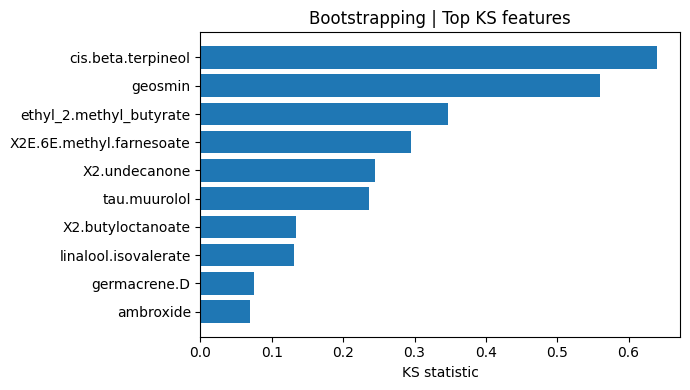

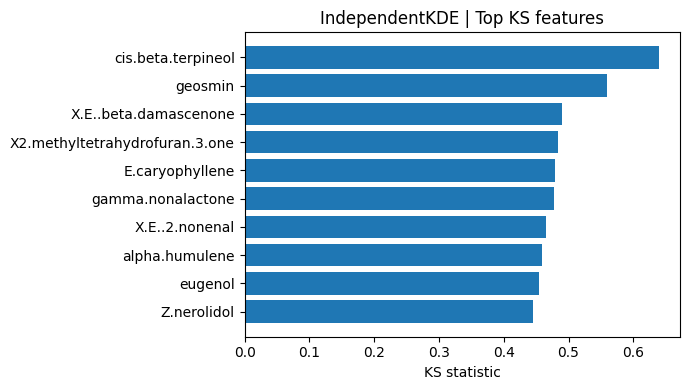

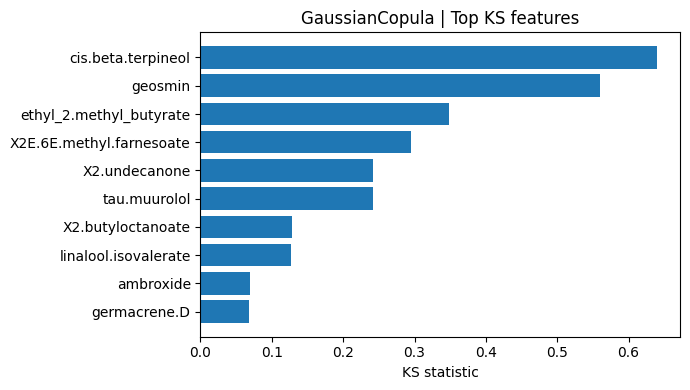

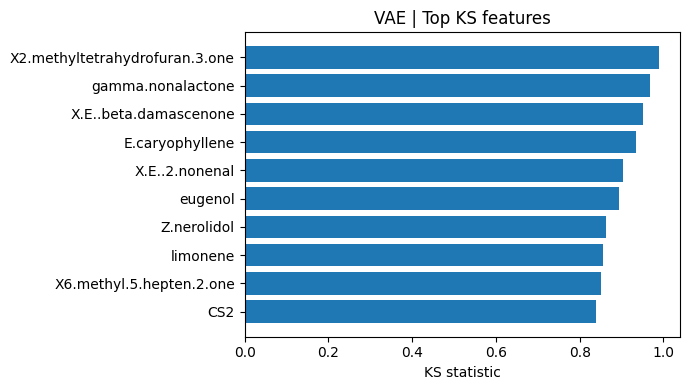

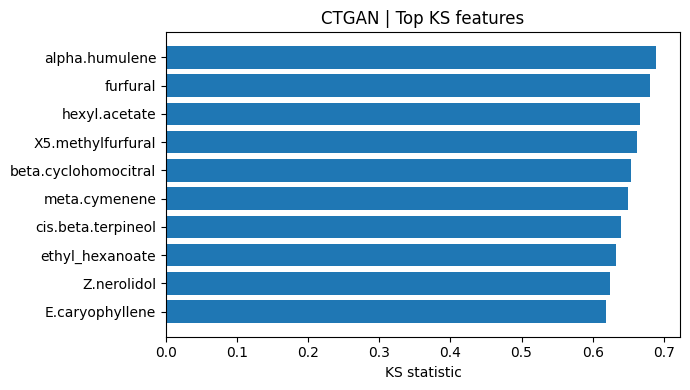

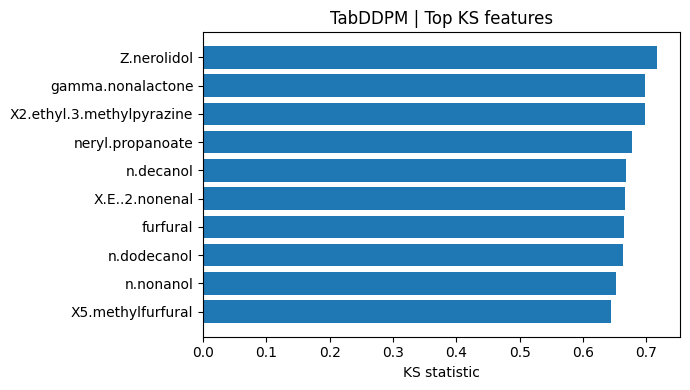

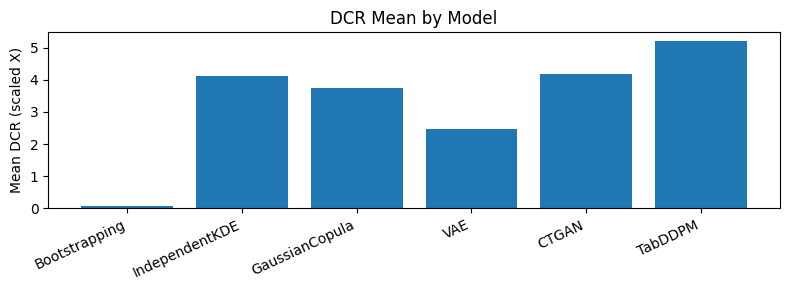

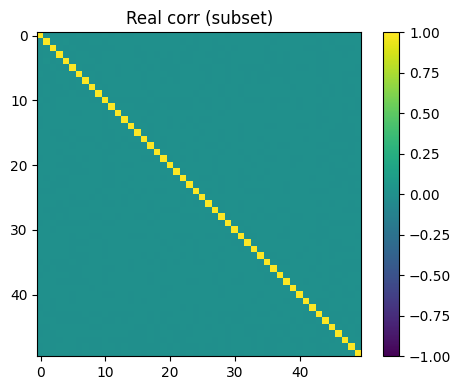

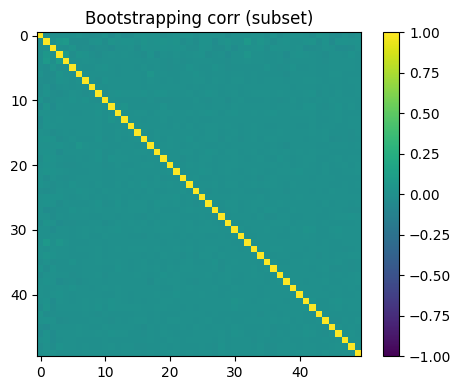

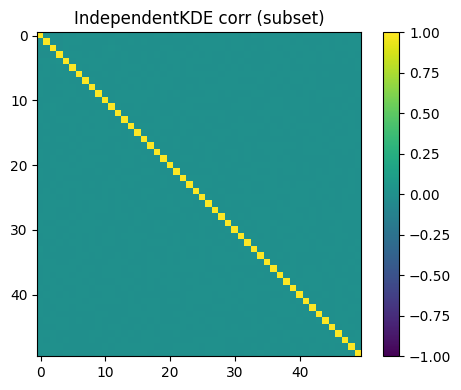

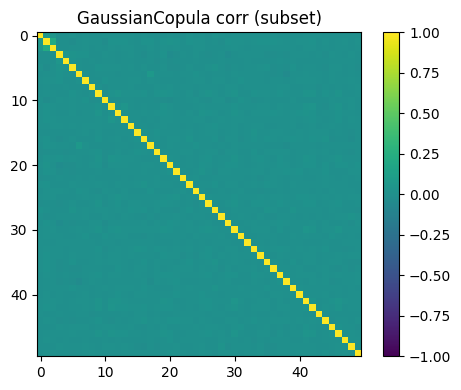

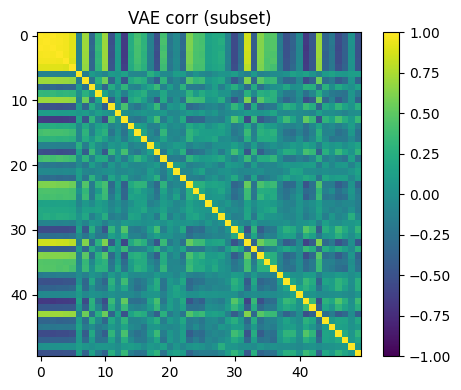

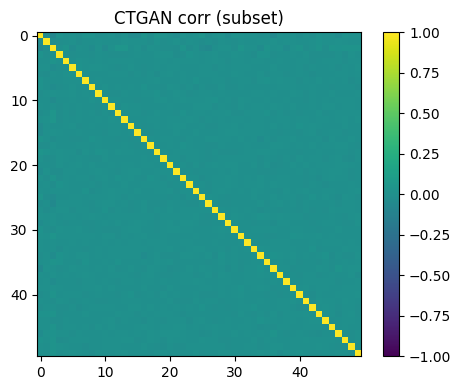

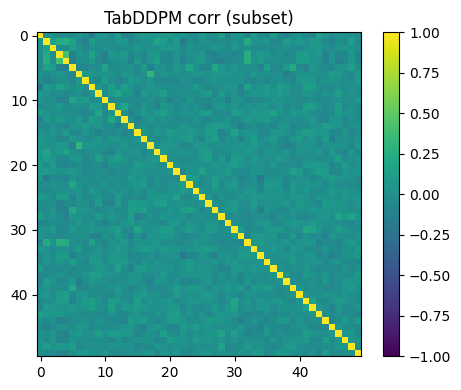

In [22]:

def plot_top_ks(ks_df, topk=10, title=""):
    dfp = ks_df.sort_values("ks_stat", ascending=False).head(topk)
    plt.figure(figsize=(7, 4))
    plt.barh(dfp["feature"][::-1], dfp["ks_stat"][::-1])
    plt.xlabel("KS statistic")
    plt.title(title or f"Top-{topk} KS")
    plt.tight_layout()
    plt.show()

def plot_dcr_means(dcr_tables):
    names = list(dcr_tables.keys())
    vals = [dcr_tables[n]["dcr_syn_mean"] for n in names]
    plt.figure(figsize=(8, 3))
    plt.bar(names, vals)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Mean DCR (scaled X)")
    plt.title("DCR Mean by Model")
    plt.tight_layout()
    plt.show()

def plot_corr_heatmap(C, title, vmax=1.0):
    plt.figure(figsize=(5,4))
    plt.imshow(C, vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

display(results_df)

for name, ks_df in ks_tables.items():
    plot_top_ks(ks_df, topk=10, title=f"{name} | Top KS features")

plot_dcr_means(dcr_tables)

# correlation subset: top variance features in X_train_pcd
var = np.var(X_train_pcd, axis=0)
top_idx = np.argsort(var)[::-1][:50]

C_real = pcd_tables[synths[0].name]["C_real"][np.ix_(top_idx, top_idx)]
plot_corr_heatmap(C_real, "Real corr (subset)", vmax=1.0)

for syn in synths:
    C_syn = pcd_tables[syn.name]["C_syn"][np.ix_(top_idx, top_idx)]
    plot_corr_heatmap(C_syn, f"{syn.name} corr (subset)", vmax=1.0)

## 12. (권장) Repeated splits / seeds
논문 표에는 평균±표준편차 보고를 권장합니다. (Small N variance)

In [23]:

DO_REPEATS = False
REPEATS = 5

if DO_REPEATS:
    # Example: compare GaussianCopula vs VAE vs TabDDPM
    selected = [
        GaussianCopulaSynthesizer(seed=0),
        VAESynthesizer(seed=0),
        TabDDPMSynthesizer(seed=0, timesteps=200, max_epochs=2000, patience=200),
    ]
    rows = []
    for r in range(REPEATS):
        seed_everything(100+r)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_raw, y_raw, test_size=0.2, random_state=100+r, stratify=strat
        )
        pre_r = BeerPreprocessor(mode=MODE).fit(X_tr, y_tr)
        X_tr_s, X_te_s = pre_r.transform_X(X_tr), pre_r.transform_X(X_te)
        y_tr_s, y_te_s = pre_r.transform_y(y_tr), pre_r.transform_y(y_te)

        for syn in selected:
            # set seed if attribute exists
            if hasattr(syn, "seed"):
                syn.seed = 100+r
            syn.fit(X_tr_s, y_tr_s)
            Xs_syn, ys_syn = syn.sample(N_SYNTH)
            # utility on original y
            y_syn = pre_r.inverse_transform_y(ys_syn)
            tstr = tstr_torch_mlp(Xs_syn, y_syn, X_te_s, y_te, seed=100+r)
            rows.append({"repeat": r, "model": syn.name, **tstr})

    rep_df = pd.DataFrame(rows)
    display(rep_df)
    display(rep_df.groupby("model")[["r2_mean","rmse_mean"]].agg(["mean","std"]))